In [64]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report,f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv("../data/processed/customer.csv")

In [66]:
X = df.drop('Churn',axis = 1)
y = df['Churn']

In [67]:
X_tr,X_val,y_tr,y_val = train_test_split(X,y,test_size=0.25,random_state=42)

### **Model Training**

- Training with Default Parameter

In [68]:
models = {
    "Decision_Tree": DecisionTreeClassifier(random_state=42),
    "Random_Forest": RandomForestClassifier(random_state=42),
    "Xgboost": XGBClassifier(random_state=42)
}

In [69]:
#dict to store cross-validation results
cv_score = {}

for name,model in models.items():
    print(f"Training {name} with default params")
    scores = cross_val_score(model,X_tr, y_tr,cv=5,scoring="accuracy")
    cv_score[name] = scores
    print(f"Name: {name} | Cross_validation_Accuracy: {np.mean(scores):.2f}")
    print("_"*50)

Training Decision_Tree with default params
Name: Decision_Tree | Cross_validation_Accuracy: 0.73
__________________________________________________
Training Random_Forest with default params
Name: Random_Forest | Cross_validation_Accuracy: 0.79
__________________________________________________
Training Xgboost with default params
Name: Xgboost | Cross_validation_Accuracy: 0.78
__________________________________________________


In [70]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [None, 10, 30],
    'clf__min_samples_split': [2, 5],
    'clf__class_weight': [None, 'balanced'],
    'clf__max_leaf_nodes': [10, 60]
}

In [71]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

In [72]:
gs.fit(X_tr,y_tr)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END clf__class_weight=None, clf__max_depth=None, clf__max_leaf_nodes=10, clf__min_samples_split=2, clf__n_estimators=100; total time=   0.7s
[CV] END clf__class_weight=None, clf__max_depth=None, clf__max_leaf_nodes=10, clf__min_samples_split=2, clf__n_estimators=100; total time=   0.7s
[CV] END clf__class_weight=None, clf__max_depth=None, clf__max_leaf_nodes=10, clf__min_samples_split=2, clf__n_estimators=100; total time=   0.6s
[CV] END clf__class_weight=None, clf__max_depth=None, clf__max_leaf_nodes=10, clf__min_samples_split=5, clf__n_estimators=100; total time=   0.7s
[CV] END clf__class_weight=None, clf__max_depth=None, clf__max_leaf_nodes=10, clf__min_samples_split=2, clf__n_estimators=100; total time=   0.7s
[CV] END clf__class_weight=None, clf__max_depth=None, clf__max_leaf_nodes=10, clf__min_samples_split=2, clf__n_estimators=100; total time=   0.7s
[CV] END clf__class_weight=None, clf__max_depth=None, clf__max

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__class_weight': [None, 'balanced'], 'clf__max_depth': [None, 10, ...], 'clf__max_leaf_nodes': [10, 60], 'clf__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

In [73]:
print("Best params:", gs.best_params_)
print("Best CV score (F1):", gs.best_score_)

Best params: {'clf__class_weight': None, 'clf__max_depth': None, 'clf__max_leaf_nodes': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best CV score (F1): 0.6040311142087068


In [74]:
y_pred = gs.predict(X_val)
print("Test F1", f1_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Test F1 0.6168958742632613
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1282
           1       0.58      0.66      0.62       479

    accuracy                           0.78      1761
   macro avg       0.72      0.74      0.73      1761
weighted avg       0.79      0.78      0.78      1761



In [75]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        tree_method='hist',
        device='cuda', 
        random_state=42
    ))
])

In [76]:
param_grid = {
    'clf__n_estimators': [100, 300],
    'clf__learning_rate': [0.01, 0.1],
    'clf__max_depth': [3, 6, 10],
    'clf__scale_pos_weight': [1, 3] # Helps with churn imbalance
}

In [77]:
gs_xgb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1', # Better for churn than simple accuracy
    cv=5,
    verbose=2,
    refit=True
)

In [78]:
gs_xgb.fit(X_tr, y_tr)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


[CV] END clf__learning_rate=0.01, clf__max_depth=3, clf__n_estimators=100, clf__scale_pos_weight=1; total time=   0.5s
[CV] END clf__learning_rate=0.01, clf__max_depth=3, clf__n_estimators=100, clf__scale_pos_weight=1; total time=   0.4s
[CV] END clf__learning_rate=0.01, clf__max_depth=3, clf__n_estimators=100, clf__scale_pos_weight=1; total time=   0.2s
[CV] END clf__learning_rate=0.01, clf__max_depth=3, clf__n_estimators=100, clf__scale_pos_weight=1; total time=   0.2s
[CV] END clf__learning_rate=0.01, clf__max_depth=3, clf__n_estimators=100, clf__scale_pos_weight=1; total time=   0.2s
[CV] END clf__learning_rate=0.01, clf__max_depth=3, clf__n_estimators=100, clf__scale_pos_weight=3; total time=   0.2s
[CV] END clf__learning_rate=0.01, clf__max_depth=3, clf__n_estimators=100, clf__scale_pos_weight=3; total time=   0.1s
[CV] END clf__learning_rate=0.01, clf__max_depth=3, clf__n_estimators=100, clf__scale_pos_weight=3; total time=   0.1s
[CV] END clf__learning_rate=0.01, clf__max_depth

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 6, ...], 'clf__n_estimators': [100, 300], 'clf__scale_pos_weight': [1, 3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [79]:
print("Best params:", gs_xgb.best_params_)
print("Best CV score (F1):", gs_xgb.best_score_)

Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__scale_pos_weight': 3}
Best CV score (F1): 0.6160413279334571


In [80]:
y_pred = gs_xgb.predict(X_val)
print("Test F1:", f1_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Test F1: 0.6400625978090767
              precision    recall  f1-score   support

           0       0.93      0.70      0.80      1282
           1       0.51      0.85      0.64       479

    accuracy                           0.74      1761
   macro avg       0.72      0.77      0.72      1761
weighted avg       0.81      0.74      0.75      1761



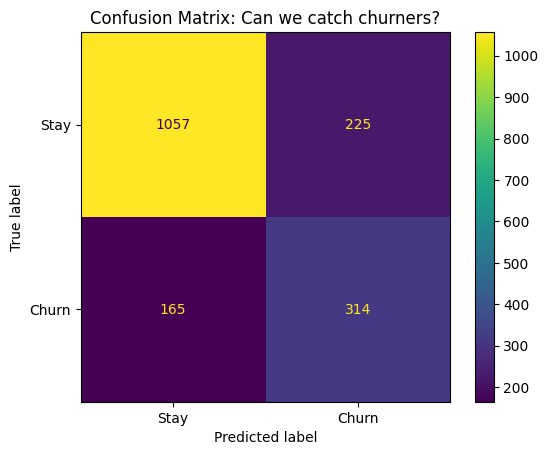

In [81]:
ConfusionMatrixDisplay.from_estimator(gs, X_val, y_val, display_labels=['Stay', 'Churn'])
plt.title("Confusion Matrix: Can we catch churners?")
plt.show()